# 0 · Data Preprocessing — SDNET2018 Concrete Crack Dataset

### 1. Imports & Paths

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from src.dataset import (
    build_image_index, CrackDataset,
    save_splits, load_splits,
    _lime_preprocess, _clahe_preprocess,
)

DATASET_DIR  = 'SDNET2018'
SPLITS_DIR   = 'splits'
BATCH_SIZE   = 64
RANDOM_STATE = 42

print('PyTorch version:', torch.__version__)
print('CUDA available :', torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
CUDA available : True


### 2. Dataset Overview

Bridge Deck      Normal: 11,595  Cracked: 2,025  Crack%: 14.9%
Pavement         Normal: 21,726  Cracked: 2,608  Crack%: 10.7%
Wall             Normal: 14,287  Cracked: 3,851  Crack%: 21.2%

TOTAL            Normal: 47,608  Cracked: 8,484  Crack%: 15.1%


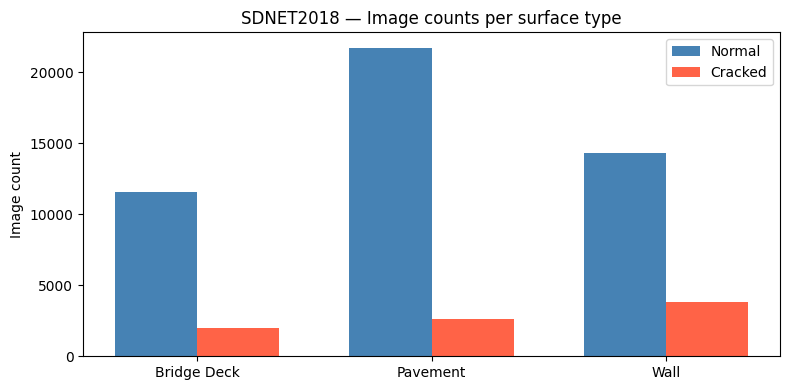

In [4]:
# Count images per surface type and crack status
surface_names = {'D': 'Bridge Deck', 'P': 'Pavement', 'W': 'Wall'}
subdirs = {'D': ('UD', 'CD'), 'P': ('UP', 'CP'), 'W': ('UW', 'CW')}

rows = []
for s, (u, c) in subdirs.items():
    n_normal = len(os.listdir(os.path.join(DATASET_DIR, s, u)))
    n_crack  = len(os.listdir(os.path.join(DATASET_DIR, s, c)))
    rows.append((surface_names[s], n_normal, n_crack))
    print(f"{surface_names[s]:15s}  Normal: {n_normal:>6,}  Cracked: {n_crack:>5,}  "
          f"Crack%: {n_crack/(n_normal+n_crack)*100:.1f}%")

total_n = sum(r[1] for r in rows)
total_c = sum(r[2] for r in rows)
print(f"\n{'TOTAL':15s}  Normal: {total_n:>6,}  Cracked: {total_c:>5,}  "
      f"Crack%: {total_c/(total_n+total_c)*100:.1f}%")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(rows))
w = 0.35
ax.bar(x - w/2, [r[1] for r in rows], w, label='Normal', color='steelblue')
ax.bar(x + w/2, [r[2] for r in rows], w, label='Cracked', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels([r[0] for r in rows])
ax.set_ylabel('Image count')
ax.set_title('SDNET2018 — Image counts per surface type')
ax.legend()
plt.tight_layout()
plt.show()

### 3. Build Image Index & Split

In [5]:
import importlib, src.dataset
importlib.reload(src.dataset)
from src.dataset import build_image_index, CrackDataset, save_splits

SURFACE = 'P'   # restrict to one surface type: 'D' = Bridge Deck, 'P' = Pavement, 'W' = Wall

all_records = build_image_index(DATASET_DIR, surface_types=[SURFACE])
labels_all  = np.array([r['label'] for r in all_records])
n0 = (labels_all == 0).sum()
n1 = (labels_all == 1).sum()
surface_full = {'D': 'Bridge Deck', 'P': 'Pavement', 'W': 'Wall'}[SURFACE]
print(f'Surface      : {SURFACE} ({surface_full} only)')
print(f'Total images : {len(all_records):,}')
print(f'Normal       : {n0:,} ({n0/len(all_records)*100:.1f}%)')
print(f'Cracked      : {n1:,} ({n1/len(all_records)*100:.1f}%)')

Surface      : P (Pavement only)
Total images : 24,334
Normal       : 21,726 (89.3%)
Cracked      : 2,608 (10.7%)


### 4. Train / Val / Test Split (70 / 15 / 15)

Stratified split preserves the ~85/15 normal/cracked ratio across all three sets.  
One-class models (Deep SVDD, Autoencoder, PatchCore) train on **normal images only**.

In [74]:
train_records, temp_records = train_test_split(
    all_records, test_size=0.30, stratify=labels_all, random_state=RANDOM_STATE,
)
temp_labels = np.array([r['label'] for r in temp_records])
val_records, test_records = train_test_split(
    temp_records, test_size=0.50, stratify=temp_labels, random_state=RANDOM_STATE,
)

for name, recs in [('Train', train_records), ('Val', val_records), ('Test', test_records)]:
    lbs = np.array([r['label'] for r in recs])
    n0, n1 = (lbs==0).sum(), (lbs==1).sum()
    print(f"{name:5s}: {len(recs):>7,} images  "
          f"| Normal {n0:>6,} ({n0/len(recs)*100:.1f}%)  "
          f"| Cracked {n1:>5,} ({n1/len(recs)*100:.1f}%)")

save_splits(train_records, val_records, test_records, SPLITS_DIR)

Train:  17,033 images  | Normal 15,207 (89.3%)  | Cracked 1,826 (10.7%)
Val  :   3,650 images  | Normal  3,259 (89.3%)  | Cracked   391 (10.7%)
Test :   3,651 images  | Normal  3,260 (89.3%)  | Cracked   391 (10.7%)
Splits saved to splits/
  train: 17,033 images
  val:   3,650 images
  test:  3,651 images
